## **Belief Dynamics Learning for Contact-Rich Robotic Manipulation via Differentiable Particle Filters (DPF)**

In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from belief_dynamics_learning.world2d import World2D
from belief_dynamics_learning.dpf import *
from belief_dynamics_learning.dpf_utils import *
import random

%load_ext autoreload
%autoreload 2

### **1. Example demonstration of 2D world**

In [2]:
num_particles = 100
dt = 0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05

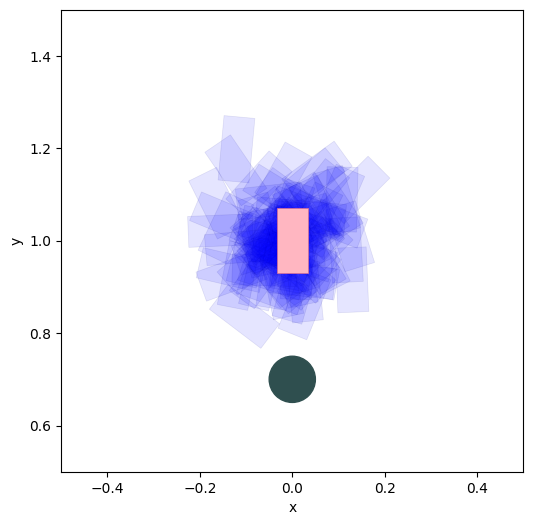

In [3]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

In [4]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

print('Ground truth object pose:', world.qo_gt)

# only keep bits of sequence around positive contact measurements
contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)

Ground truth object pose: [-0.12441938  0.92293478  2.40585232]
No contact detected


### **2.1. Initialize DPF and load dataset**

In [40]:
# initialise hyperparameters for the differentiable particle filter (DPF)
propose_ratio = 0.7
proposer_keep_ratio = 0.15 # what it was set to initially and from the paper code
min_obs_likelihood = 0.004
threshold_np = 0.9

# initialise hyperparameters for the DPF training
split_ratio = 0.8
seq_len = 1000
batch_size = 20
num_epochs_pp = 100
num_epochs_ole = 300
num_epochs_np = 100
patience = 10
learning_rate = 0.0003
learning_rate_ole = 0.005
dropout_keep_ratio = 0.7
num_particles = 100
num_particles_test = 500
particle_std = 0.2

# dataset descriptors
contact_only = False # use True here, if generate_dataset_contact_only() method was used to generate data
xy_only = False # use if we ignore the theta state
phi_dataset = True # use if dataset contains trajectories with contact obserations (phi values)

# create instance of DPF class
dpf = DPF(propose_ratio, proposer_keep_ratio, min_obs_likelihood, num_particles, num_particles_test, world, xy_only, phi_dataset)

Using device: cpu


In [41]:
# find file path to the training data
root = os.getcwd()
save_path = os.path.join(root, '../data/phi_data_min_10_contacts_seq_len_1000_test_500_trajectories.pkl')

# ensure the training data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print("File not found:", save_path)

Organise data into a dictionary:

Object pose data: (500, 1, 3)
Robot pose data: (500, 1000, 2)
q_o_r data: (500, 1000, 2)
Observation data (500, 1000, 1)
Phi observation data: (500, 1000, 1)
Closest point data: (500, 1000, 2)
Object pose (example trajectory): [[-0.17011717  0.84183382  1.20879447]]
Robot pose (example trajectory): [0.01722731 0.91900938]
q_o_r data (example trajectory): [-0.18734448 -0.07717556]
Observation data [0.]
Phi observation (example trajectory): [-2.14156513]
Closest point (example trajectory): [-0.11001727 -0.070637  ]


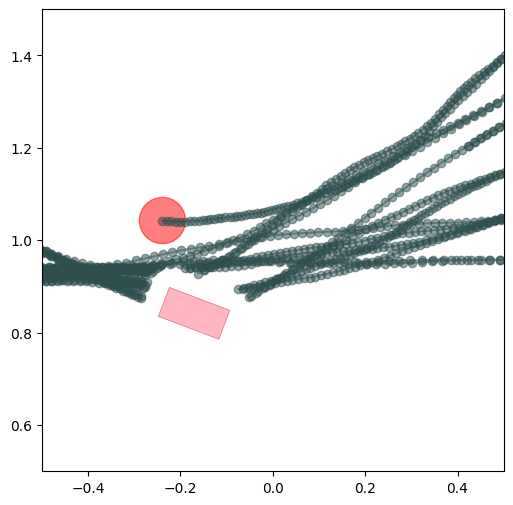

In [42]:
# data generation parameters
num_sequences = 500
num_steps_per_sequence = seq_len

data = organise_data(raw_data, num_sequences, num_steps_per_sequence, contact_only, xy_only)
    
# verify shapes of matrices containing 
print('Object pose data:', data['q_o'].shape)
print('Robot pose data:', data['q_r'].shape)
print('q_o_r data:', data['q_o_r'].shape)
print('Observation data', data['o'].shape)
print('Phi observation data:', data['phi'].shape)
print('Closest point data:', data['cp'].shape)

# plot example trajectory from the dataset
traj = np.random.randint(0, num_sequences)
step = np.random.randint(0, num_steps_per_sequence)
print('Object pose (example trajectory):', data['q_o'][traj, :, :])
print('Robot pose (example trajectory):', data['q_r'][traj, step, :])
print('q_o_r data (example trajectory):', data['q_o_r'][traj, step, :])
print('Observation data', data['o'][traj, step, :])
print('Phi observation (example trajectory):', data['phi'][traj, step, :])
print('Closest point (example trajectory):', data['cp'][traj, step, :])
world.qo_gt = data['q_o'][traj, 0, :]
world.plot_rollout(data['q_r'][traj, :, :], 1)

In [43]:
# compute some statistics aboout the data
means, stds, q_o_r_maxs, q_o_r_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data, phi_dataset)

### **2.2. DPF Training**

Before training, test the:
- particle proposer
- observation likelihood estimator

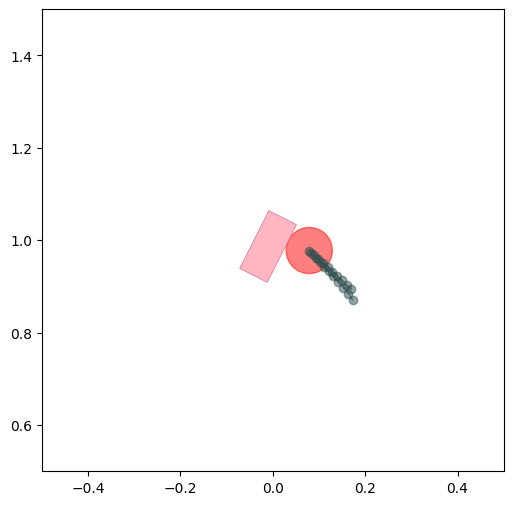

Desired robot position during contact event: tensor([[0.0743, 0.9803]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[0.0791, 0.9779]], dtype=torch.float64)
Phi during contact event: tensor([[-0.8621]], dtype=torch.float64)


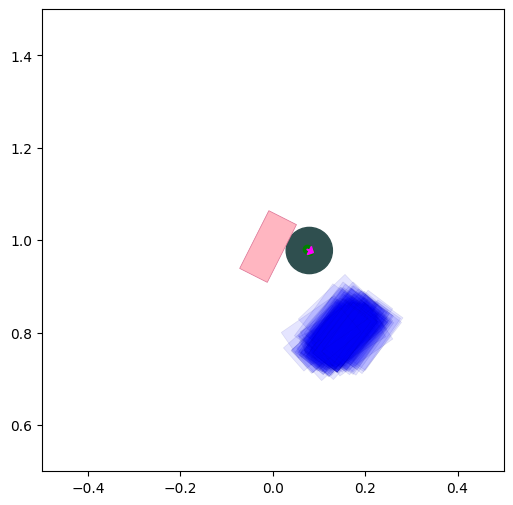

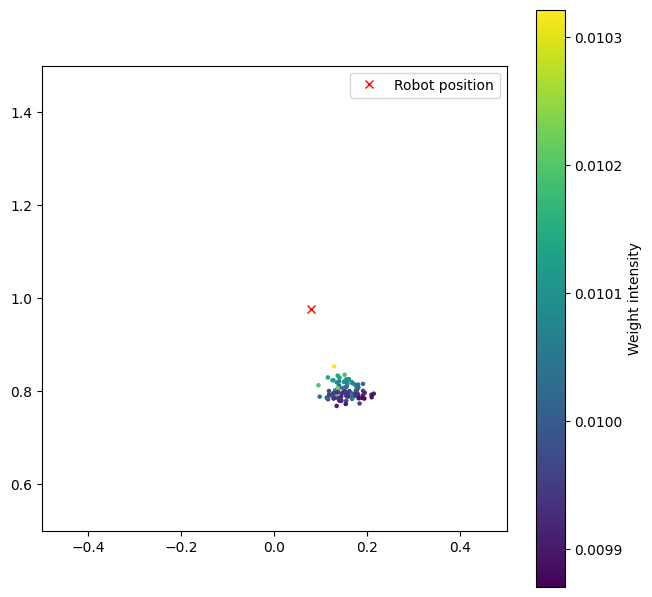

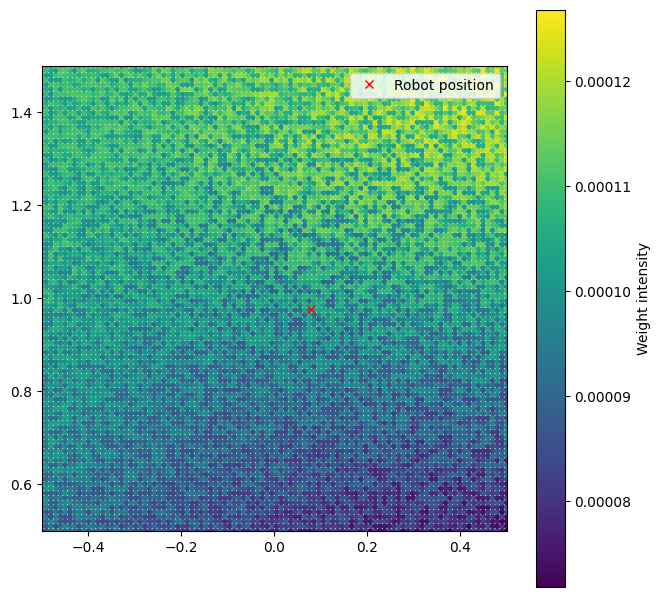

In [45]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

TRAINING PARTICLE PROPOSER:
Epoch 1/100
Epoch 11/100
Epoch 21/100
Epoch 31/100
Epoch 41/100
Epoch 51/100
Epoch 61/100
Epoch 71/100
Epoch 81/100
Epoch 91/100
TRAINING OBSERVATION LIKELIHOOD ESTIMATOR:
Epoch 1/300
Epoch 11/300
Epoch 21/300
Epoch 31/300
Epoch 41/300
Epoch 51/300
Epoch 61/300
Epoch 71/300
Epoch 81/300
Epoch 91/300
Epoch 101/300
Epoch 111/300
Epoch 121/300
Epoch 131/300
Epoch 141/300
Epoch 151/300
Epoch 161/300
Epoch 171/300
Epoch 181/300
Epoch 191/300
Epoch 201/300
Epoch 211/300
Epoch 221/300
Epoch 231/300
Epoch 241/300
Epoch 251/300
Epoch 261/300
Epoch 271/300
Epoch 281/300
Epoch 291/300


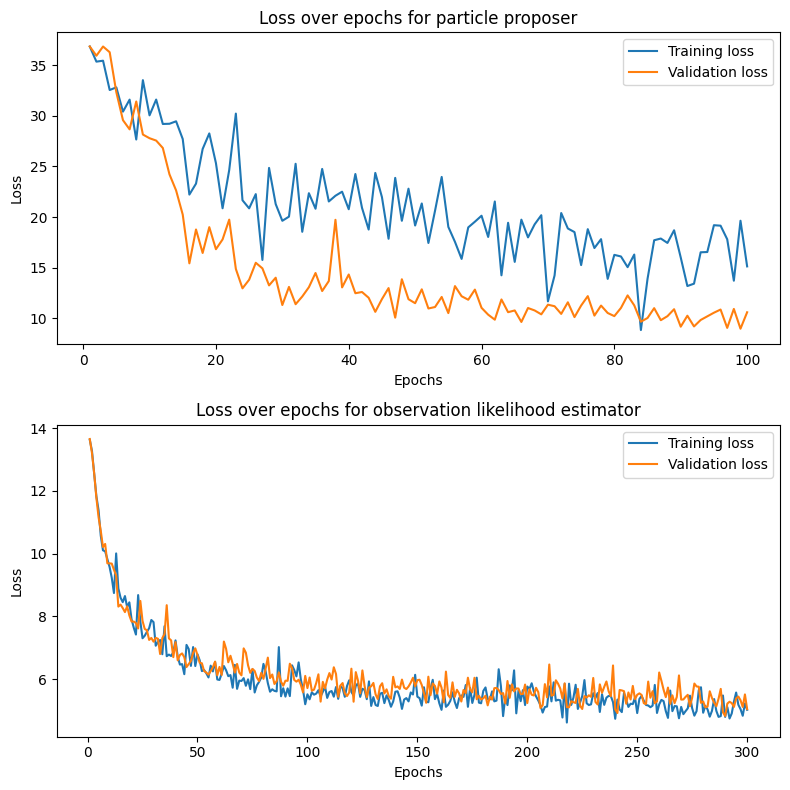

In [46]:
if contact_only == True:
    seq_len = 1

# number of contact events per trajectory during training
num_contacts_desired = 10

# train the dpf with resampling
dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs_pp, num_epochs_ole, num_epochs_np, learning_rate, learning_rate_ole, num_particles, xy_only, phi_dataset, num_contacts_desired, threshold_np)

After training, test the:
- particle proposer
- observation likelihood estimator

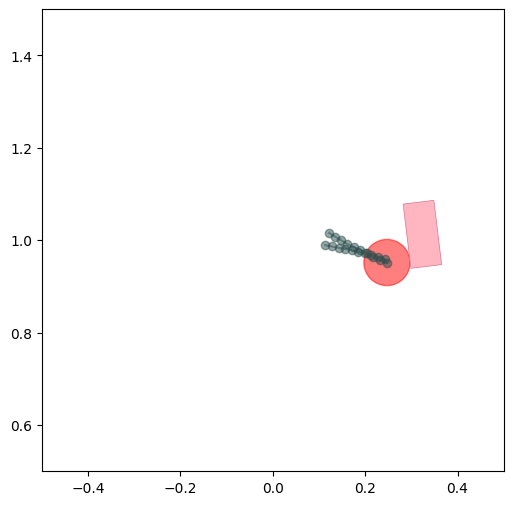

Desired robot position during contact event: tensor([[0.2575, 0.9531]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[0.2472, 0.9519]], dtype=torch.float64)
Phi during contact event: tensor([[1.3805]], dtype=torch.float64)


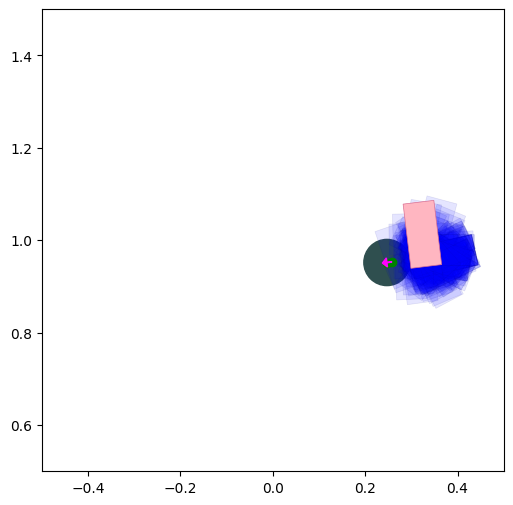

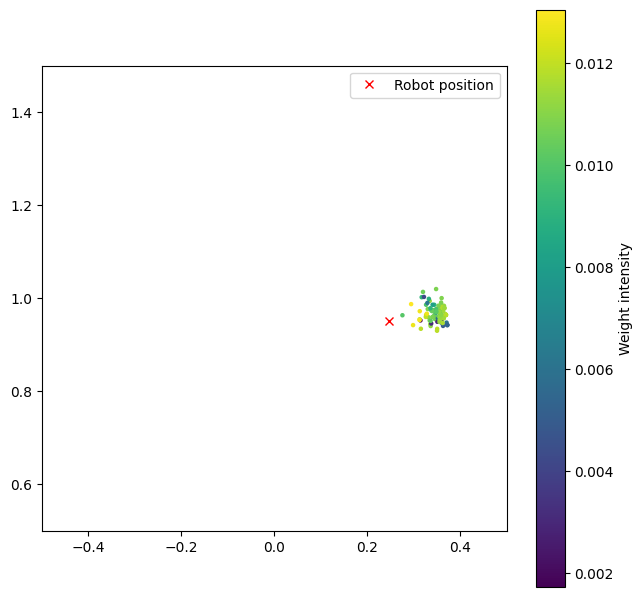

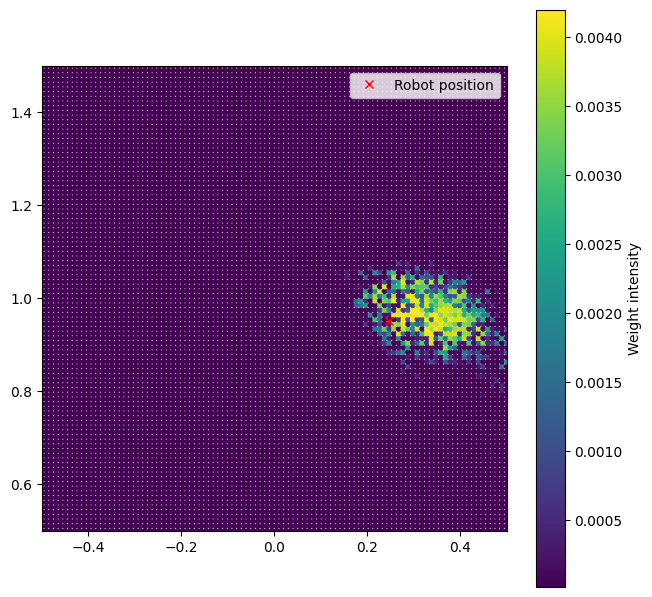

In [48]:
# single timestep testing
# note that the data is generated when the code block is run (not a consistent test datum)
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

### **3. DPF Evaluation**

In [12]:
# find file path to the test data
root = os.getcwd()
# save_path = os.path.join(root, '../data/test_data_min_10_contacts_seq_len_1000_test_200_trajectories.pkl') # random trajectories
save_path = os.path.join(root, '../data/opt_traj_data_min_10_contacts_seq_len_1000_test_10_trajectories.pkl') # "optimal" trajectories --> plotting is weird for some reason

# ensure the test data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_test_data = pickle.load(f)
else:
    print("File not found:", save_path)

In [13]:
# data generation parameters
num_sequences = 10
num_steps_per_sequence = seq_len
data = organise_data(raw_test_data, num_sequences, num_steps_per_sequence, contact_only, xy_only)

In [14]:
# compute some statistics aboout the data
means, stds, q_o_r_maxs, q_o_r_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data, phi_dataset)

Visualize the convergence of the belief using trained DPF:

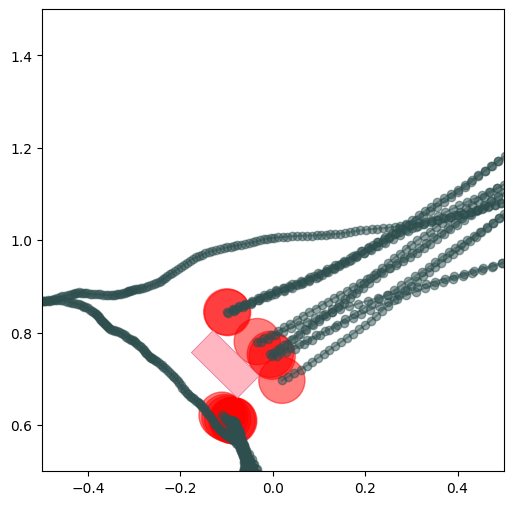

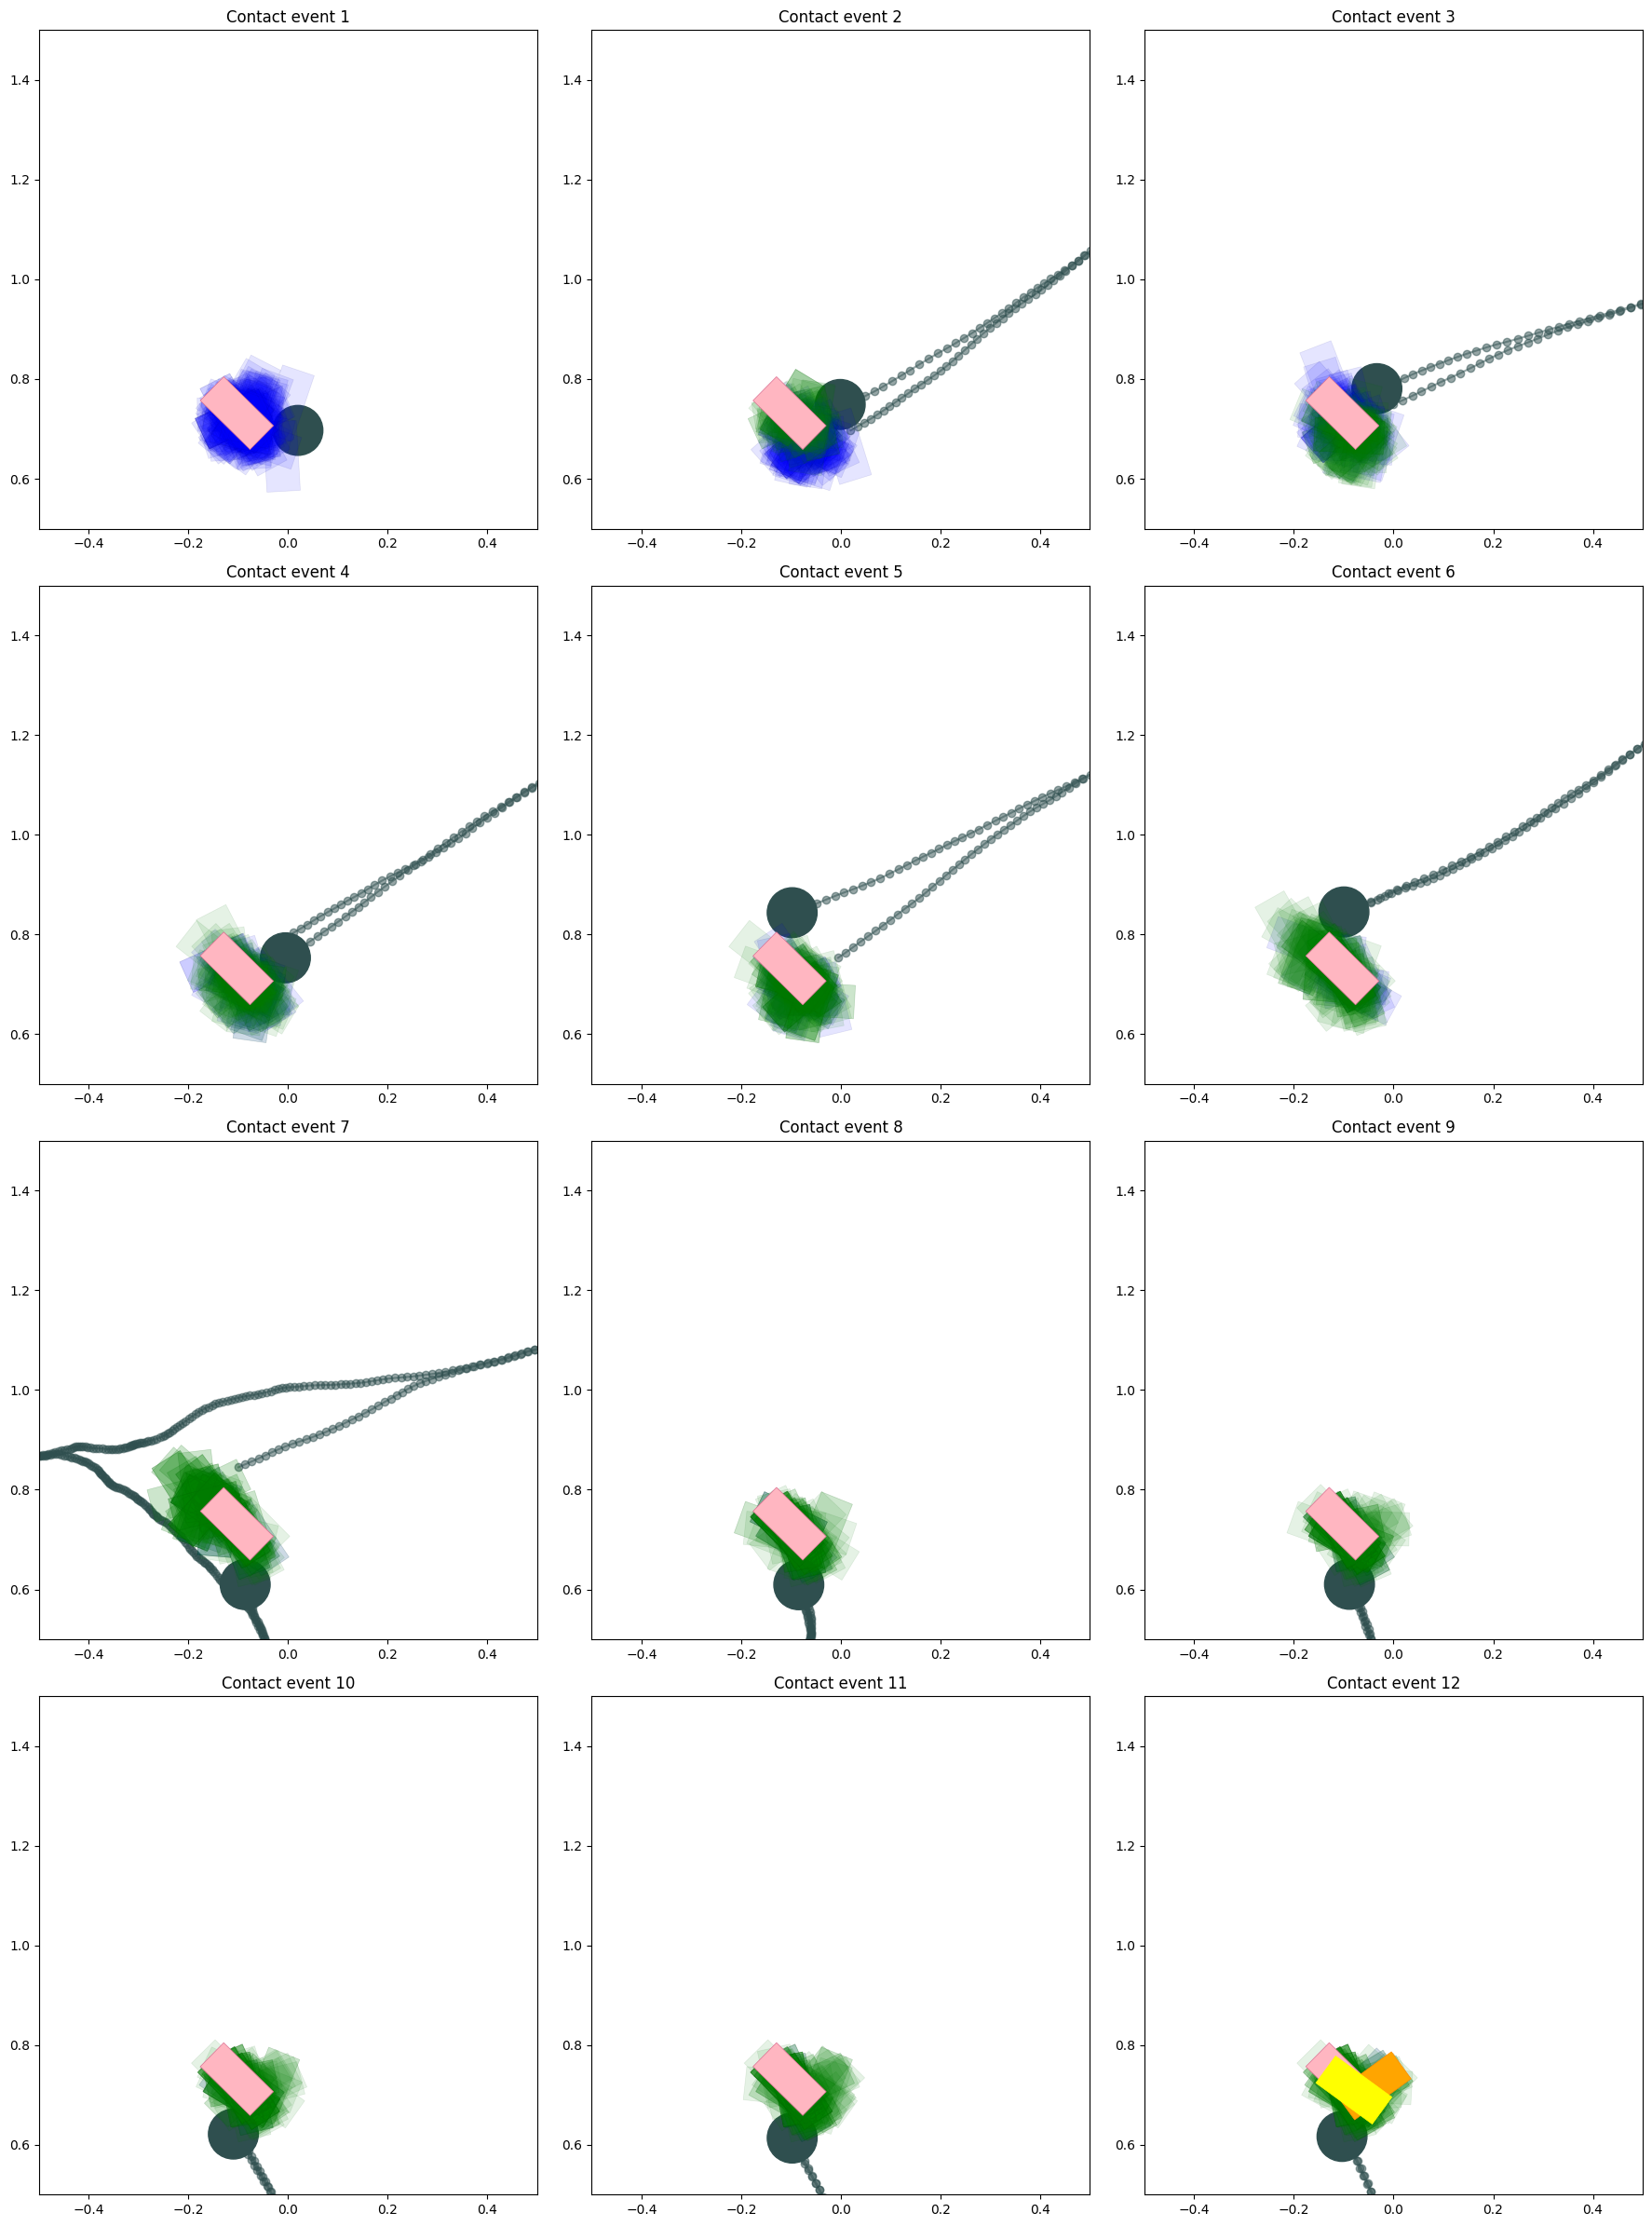

In [77]:
compute_metrics = False
traj = np.random.randint(0, num_sequences) # sample random trajectory
qo_gt = data['q_o'][traj, 0, :]
q_r_hist = data['q_r'][traj, :, :]
o_hist = data['o'][traj, :, :]
phi_hist = data['phi'][traj, :, :]
dpf.test_resampling_non_contact_only(qo_gt, q_r_hist, o_hist, phi_hist, q_o_r_mins, q_o_r_maxs, means, stds, xy_only, compute_metrics)

Evaluate DPF without negative proposer (NP):

In [16]:
# TEST AND COMPUTE METRICS WITHOUT NEGATIVE PROPOSER
num_test_samples = num_sequences
compute_metrics = True
threshold_np = 0.01
margin_np = 0
activate_np = False
MSE_max_particle_xy, MSE_max_particle_theta, MSE_avg_particle_xy, MSE_avg_particle_theta = dpf.compute_metrics(data, q_o_r_mins, q_o_r_maxs, means, stds, xy_only, compute_metrics, num_test_samples, threshold_np, margin_np, activate_np)

100%|██████████| 10/10 [00:00<00:00, 184.61it/s]

xy MSE for particle with max probability:  0.0016620209207758307
theta MSE for particle with max probability:  2.178114414215088
xy MSE for average particle from the final belief:  0.0018455313984304667
theta MSE for average particle from the final belief:  1.086936116218567


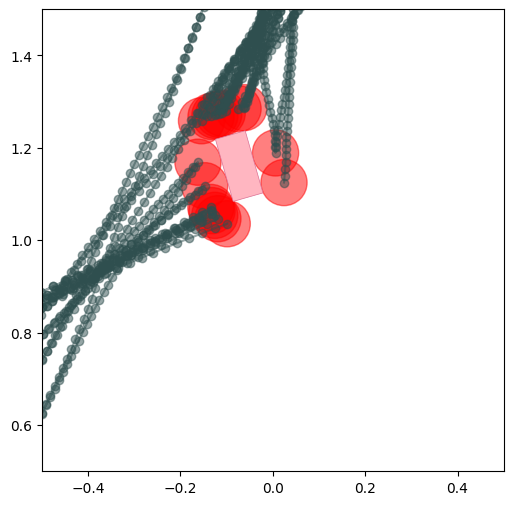

Total number of particles eradicated throughout trajectory:  17227


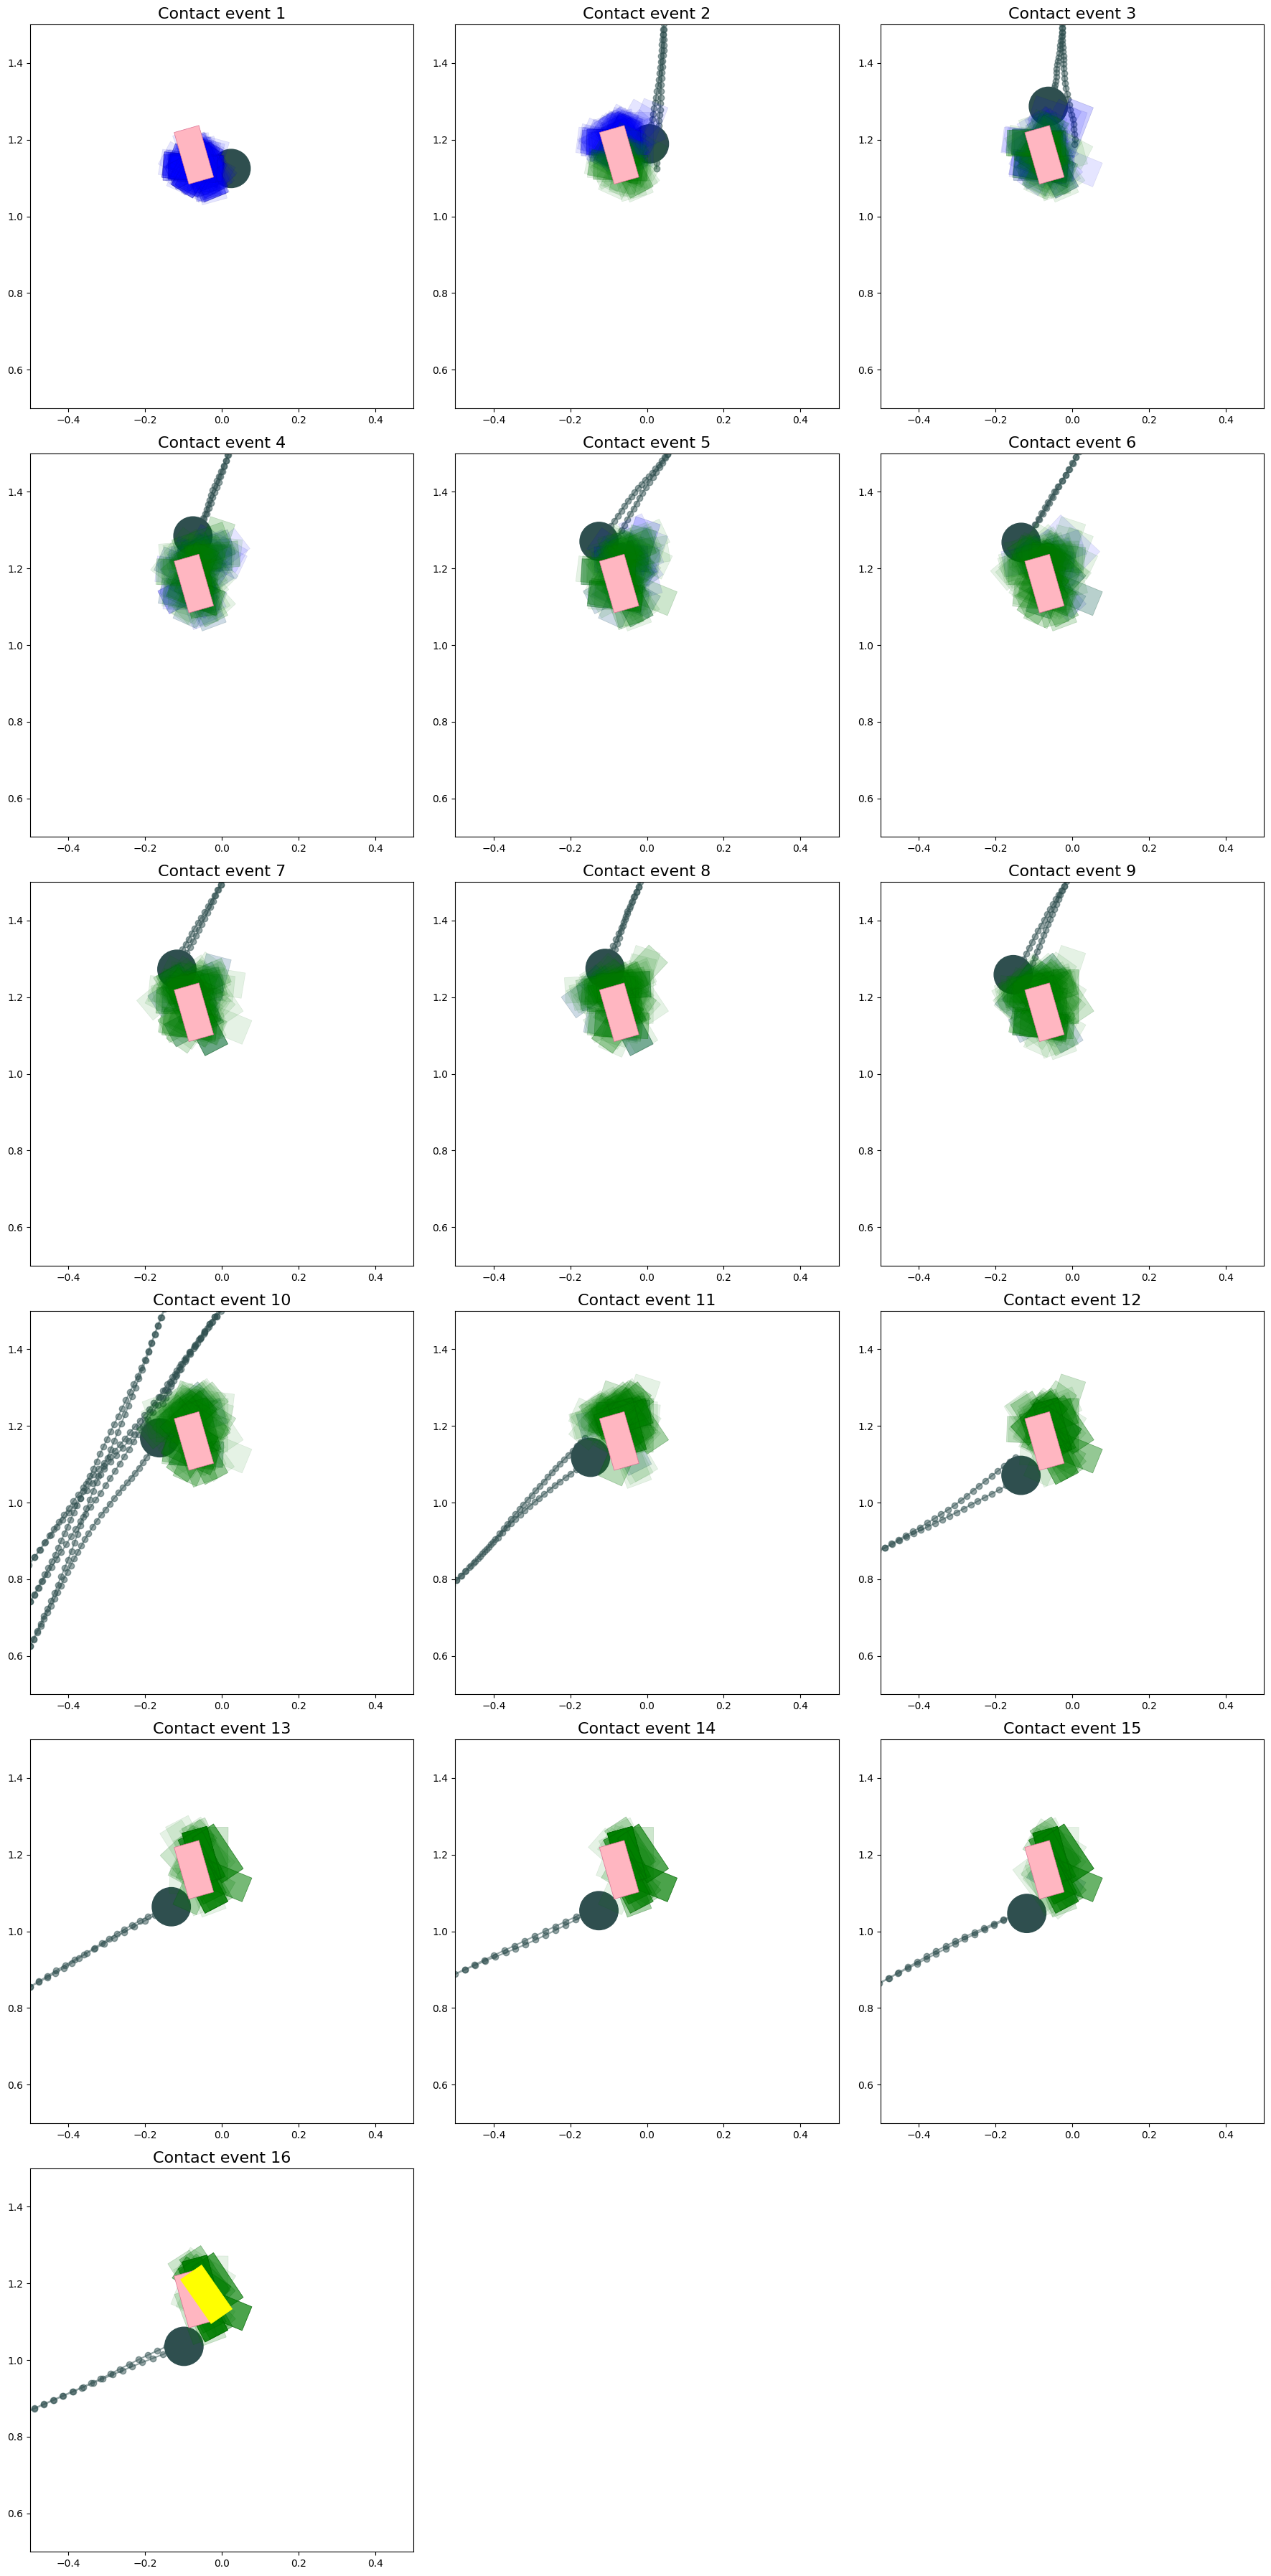

In [17]:
compute_metrics = False
threshold_np = 0.01 # get rid of around 99 percent of intersecting particles at a given non-contact timestep
margin_np = 0.01 # how much intersection (how negative d = dist_to_object) required to trigger negative proposing
traj = np.random.randint(0, num_sequences) # sample random trajectory
qo_gt = data['q_o'][traj, 0, :]
q_r_hist = data['q_r'][traj, :, :]
o_hist = data['o'][traj, :, :]
phi_hist = data['phi'][traj, :, :]
dpf.test_with_NP(qo_gt, q_r_hist, o_hist, phi_hist, q_o_r_mins, q_o_r_maxs, means, stds, xy_only, compute_metrics, threshold_np, margin_np)

Optimising 'margin_np' hyperparameter:

100%|██████████| 10/10 [00:39<00:00,  3.90s/it]


xy MSE for particle with max probability:  0.0024313146714121103
theta MSE for particle with max probability:  1.4857721328735352
xy MSE for average particle from the final belief:  0.0018253115704283118
theta MSE for average particle from the final belief:  1.0697158575057983


100%|██████████| 10/10 [00:35<00:00,  3.51s/it]


xy MSE for particle with max probability:  0.002226924989372492
theta MSE for particle with max probability:  1.6762346029281616
xy MSE for average particle from the final belief:  0.0020573644433170557
theta MSE for average particle from the final belief:  1.1846774816513062


100%|██████████| 10/10 [00:32<00:00,  3.28s/it]


xy MSE for particle with max probability:  0.0018702693050727248
theta MSE for particle with max probability:  1.7540022134780884
xy MSE for average particle from the final belief:  0.0018714051693677902
theta MSE for average particle from the final belief:  0.9474628567695618


100%|██████████| 10/10 [00:30<00:00,  3.01s/it]


xy MSE for particle with max probability:  0.006242475938051939
theta MSE for particle with max probability:  1.3201329708099365
xy MSE for average particle from the final belief:  0.0019146620761603117
theta MSE for average particle from the final belief:  1.1901476383209229


100%|██████████| 10/10 [00:28<00:00,  2.86s/it]

xy MSE for particle with max probability:  0.002101619727909565
theta MSE for particle with max probability:  1.5063493251800537
xy MSE for average particle from the final belief:  0.0020779469050467014
theta MSE for average particle from the final belief:  0.8252954483032227


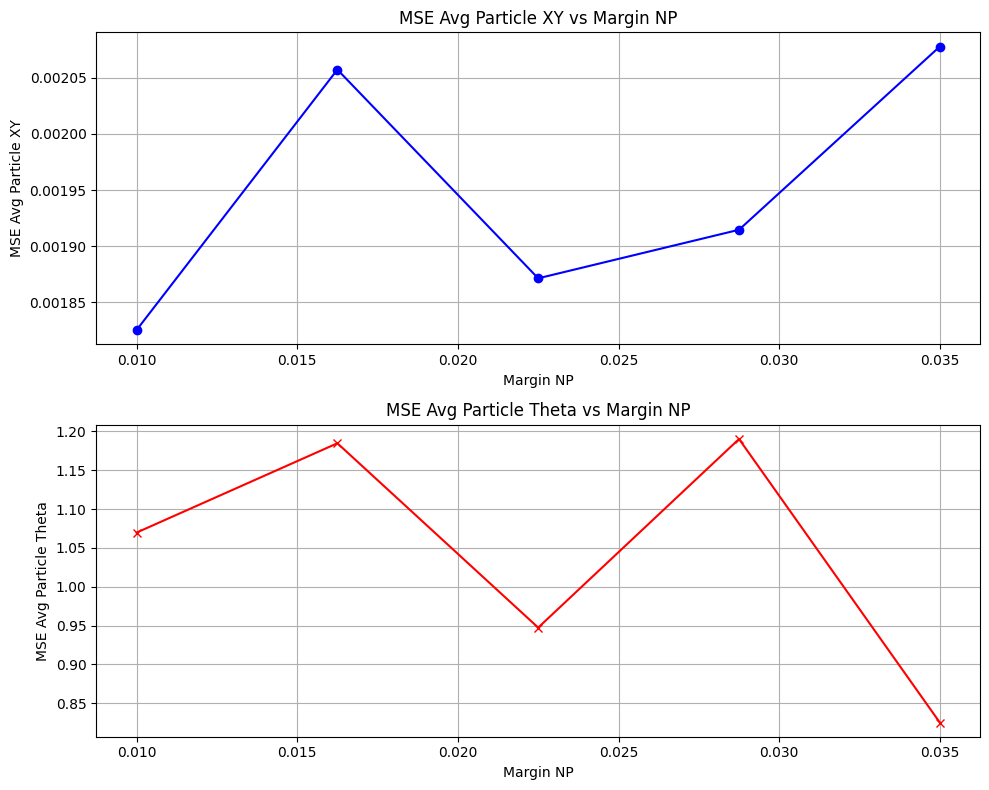

In [18]:
import matplotlib.pyplot as plt

# cross validation to figure out what value the margin_np hyperparameter should be
n = 5 # loop number for cross validation
min = 0.01
max = 0.035
margin_values = np.linspace(min, max, n)
compute_metrics = True
activate_np = True
MSE_avg_xy_list = np.zeros(n)
MSE_avg_theta_list = np.zeros(n)
i = 0

for margin_np in margin_values:  # n points include both start and end
    MSE_max_particle_xy, MSE_max_particle_theta, MSE_avg_particle_xy, MSE_avg_particle_theta = dpf.compute_metrics(data, q_o_r_mins, q_o_r_maxs, means, stds, xy_only, compute_metrics, num_test_samples, threshold_np, margin_np, activate_np)
    MSE_avg_xy_list[i] = MSE_avg_particle_xy
    MSE_avg_theta_list[i] = MSE_avg_particle_theta
    i += 1

# create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# plot MSE_avg_xy_list vs margin_np on the first subplot
ax1.plot(margin_values, MSE_avg_xy_list, color='blue', marker='o')
ax1.set_xlabel("Margin NP")
ax1.set_ylabel("MSE Avg Particle XY")
ax1.set_title("MSE Avg Particle XY vs Margin NP")
ax1.grid(True)

# plot MSE_avg_theta_list vs margin_np on the second subplot
ax2.plot(margin_values, MSE_avg_theta_list, color='red', marker='x')
ax2.set_xlabel("Margin NP")
ax2.set_ylabel("MSE Avg Particle Theta")
ax2.set_title("MSE Avg Particle Theta vs Margin NP")
ax2.grid(True)

# adjust layout and show the plot
plt.tight_layout()
plt.show()

Evaluate DPF with negative proposer (NP):

In [19]:
# TEST AND COMPUTE METRICS WITH NEGATIVE PROPOSER
compute_metrics = True
activate_np = True
margin_np = 0.01
MSE_max_particle_xy, MSE_max_particle_theta, MSE_avg_particle_xy, MSE_avg_particle_theta = dpf.compute_metrics(data, q_o_r_mins, q_o_r_maxs, means, stds, xy_only, compute_metrics, num_test_samples, threshold_np, margin_np, activate_np)

100%|██████████| 10/10 [00:39<00:00,  3.94s/it]

xy MSE for particle with max probability:  0.007048922125250101
theta MSE for particle with max probability:  1.288304328918457
xy MSE for average particle from the final belief:  0.0018223498482257128
theta MSE for average particle from the final belief:  1.0850136280059814
